# Binary-lens inverse ray-shooting geometry

This notebook uses `lcbinint.image` to compute point-source image seeds and finite-source image regions from image-plane inverse ray shooting. The single figure below separates the source plane from the image plane so caustics and critical curves are not visually conflated.

In [1]:
from pathlib import Path
import sys

for build_dir in ("build", "build_new"):
    build_path = next(
        (root / build_dir
         for root in (Path.cwd(), *Path.cwd().parents)
         if (root / build_dir).is_dir()),
        None,
    )
    if build_path is not None:
        sys.path.insert(0, str(build_path))
        break

import matplotlib.pyplot as plt
import numpy as np

import lcbinint

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
})

Choose a resonant planetary case and a source near the caustic. `q`, `s`, `x`, and `y` are the only required parameters.

In [4]:
plane = lcbinint.image.binary(
    q=1.0e-1,
    s=1.0,
    x=0.05,
    y=-0.0,
    rho=5e-2,
    n_points=900,
)

images = plane.image_table()
[
    {
        "x": float(row["x"]),
        "y": float(row["y"]),
        "magnification": float(row["magnification"]),
        "parity": int(row["parity"]),
    }
    for row in images
]

[{'x': 0.21699799884447854,
  'y': 0.0,
  'magnification': 0.09388451305921336,
  'parity': -1},
 {'x': -0.21415476733114577,
  'y': 0.0,
  'magnification': 0.1737838189905667,
  'parity': -1},
 {'x': 1.1371774618220092,
  'y': 0.9638722127679947,
  'magnification': 14.44629608086751,
  'parity': 1},
 {'x': 1.1371774618220085,
  'y': -0.9638722127679943,
  'magnification': 14.446296080867857,
  'parity': 1},
 {'x': 1.9562476775775828,
  'y': -4.4213068055438386e-16,
  'magnification': 27.624923829706685,
  'parity': -1}]

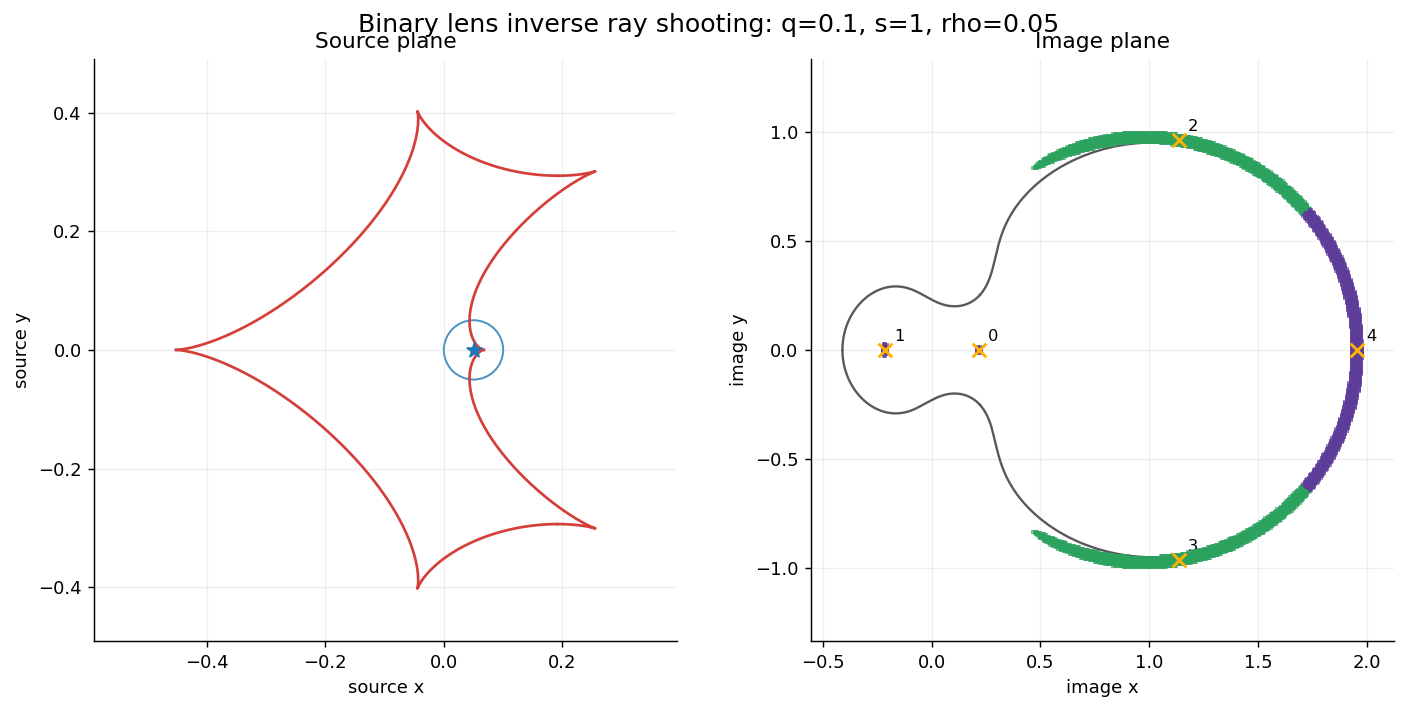

In [5]:
def plot_branches(ax, branches, *, color, lw, alpha=1.0):
    for xs, ys in zip(branches.x, branches.y):
        ax.plot(xs, ys, color=color, lw=lw, alpha=alpha)


def set_square_limits(ax, xs, ys, *, pad=0.12):
    xs = np.asarray(xs, dtype=float)
    ys = np.asarray(ys, dtype=float)
    cx = 0.5 * (np.nanmin(xs) + np.nanmax(xs))
    cy = 0.5 * (np.nanmin(ys) + np.nanmax(ys))
    span = max(np.nanmax(xs) - np.nanmin(xs), np.nanmax(ys) - np.nanmin(ys))
    span = span * (1.0 + pad) if span > 0 else 1.0
    ax.set_xlim(cx - 0.5 * span, cx + 0.5 * span)
    ax.set_ylim(cy - 0.5 * span, cy + 0.5 * span)


caustics = plane.caustics()
critical = plane.critical_curves()
regions = plane.ray_shooting_images(resolution=520)
seed_xy = plane.seeds()

fig, (ax_source, ax_image) = plt.subplots(1, 2, figsize=(11, 5.2), constrained_layout=True)

plot_branches(ax_source, caustics, color="#d43f3a", lw=1.5)
ax_source.scatter([plane.x], [plane.y], s=72, marker="*", color="#1f77b4", zorder=5)
ax_source.add_patch(plt.Circle((plane.x, plane.y), plane.rho, fill=False, color="#1f77b4", lw=1.1, alpha=0.8))
ax_source.set_title("Source plane")
ax_source.set_xlabel("source x")
ax_source.set_ylabel("source y")

source_xs = [x for branch in caustics.x for x in branch] + [plane.x - plane.rho, plane.x + plane.rho]
source_ys = [y for branch in caustics.y for y in branch] + [plane.y - plane.rho, plane.y + plane.rho]
set_square_limits(ax_source, source_xs, source_ys, pad=0.22)

plot_branches(ax_image, critical, color="0.35", lw=1.3)
region_colors = {1: "#2ca25f", -1: "#5e3c99"}
for region in regions:
    if len(region.points) == 0:
        continue
    ax_image.scatter(
        region.points[:, 0], region.points[:, 1],
        s=3, marker="s", linewidth=0, alpha=0.62,
        color=region_colors.get(region.parity, "0.25"),
        zorder=4,
    )
ax_image.scatter(seed_xy[:, 0], seed_xy[:, 1], s=58, marker="x", color="#ffb000", linewidth=1.6, zorder=6)
for region in regions:
    ax_image.annotate(str(region.index), region.seed, xytext=(5, 5), textcoords="offset points", fontsize=9)
ax_image.set_title("Image plane")
ax_image.set_xlabel("image x")
ax_image.set_ylabel("image y")

image_points = np.vstack([r.points for r in regions if len(r.points)])
image_xs = [x for branch in critical.x for x in branch] + image_points[:, 0].tolist() + seed_xy[:, 0].tolist()
image_ys = [y for branch in critical.y for y in branch] + image_points[:, 1].tolist() + seed_xy[:, 1].tolist()
set_square_limits(ax_image, image_xs, image_ys, pad=0.12)
# ax_image.set_ylim(-0.1,0.1)
# ax_image.set_xlim(-0.1,0.1)

for ax in (ax_source, ax_image):
    ax.set_aspect("equal", adjustable="box")


fig.suptitle(f"Binary lens inverse ray shooting: q={plane.q:g}, s={plane.s:g}, rho={plane.rho:g}", y=1.02, fontsize=14)
plt.show()
